In [16]:
pip install opencv-python numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


Detected skin tone season: Soft Summer


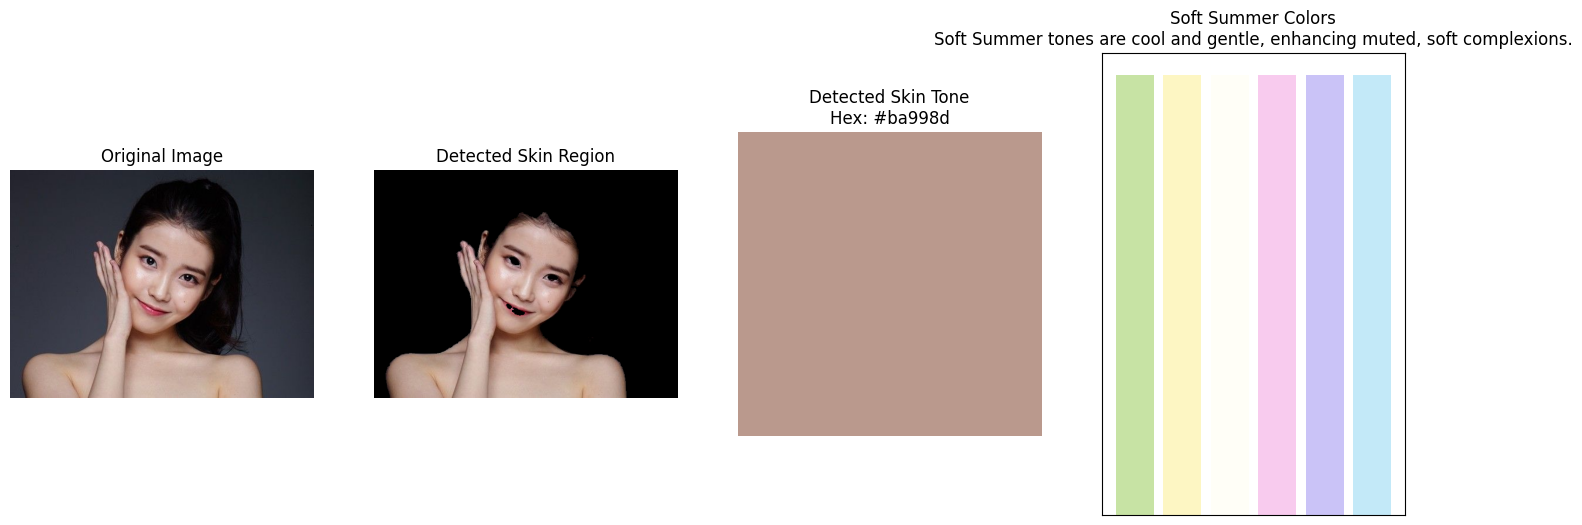

In [9]:
# import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 12-season colour palettes hex codes
subseason_palettes = {
    'Bright Winter': {
        'colors': ['#D70040', '#FF2D55', '#7F8C8D', '#FCF3CF'],
        'description': "Bright Winter tones are vibrant and high-contrast, ideal for cool, intense skin tones."
    },
    'Cool Winter': {
        'colors': ['#34495E', '#5DADE2', '#85C1E9', '#E5E8E8'],
        'description': "Cool Winter tones have icy and cool hues, emphasizing a high-contrast, cool appearance."
    },
    'Dark Winter': {
        'colors': ['#1C2833', '#212F3C', '#566573', '#85929E'],
        'description': "Dark Winter tones are deep and rich, suitable for darker cool complexions."
    },
    'Bright Spring': {
        'colors': ['#F1948A', '#F7DC6F', '#F39C12', '#F1C40F'],
        'description': "Bright Spring tones are vivid and warm, enhancing fresh, warm complexions."
    },
    'Warm Spring': {
        'colors': ['#D4AC0D', '#F5B041', '#F4D03F', '#FCF3CF'],
        'description': "Warm Spring tones are warm and golden, perfect for soft warm undertones."
    },
    'Light Spring': {
        'colors': ['#F8C471', '#F9E79F', '#FDEBD0', '#FAD7A0'],
        'description': "Light Spring tones are light and warm, providing a gentle, fresh look."
    },
    'Light Summer': {
        'colors': ['#005178', '#b0def4', '#ea8aba', '#a33f67', '#acb9ea'],
        'description': "Light Summer tones are soft and cool, ideal for cool, light skin tones."
    },
    'Cool Summer': {
        'colors': ['#fffcbe', '#ffe6d1', '#e3ffbc', '#fdffdc', '#fff1c4'],
        'description': "Cool Summer tones are muted and cool, suitable for a soft, understated look."
    },
    'Soft Summer': {
        'colors': ['#c7e3a4', '#fdf6c3', '#fffef7', '#f8cbee', '#cac3f7', '#c3e9f8'],
        'description': "Soft Summer tones are cool and gentle, enhancing muted, soft complexions."
    },
    'Soft Autumn': {
        'colors': ['#D98880', '#D7BDE2', '#E8DAEF', '#FDEDEC'],
        'description': "Soft Autumn tones are warm and muted, suitable for soft, warm complexions."
    },
    'Warm Autumn': {
        'colors': ['#ba6e58', '#c68139', '#f7ab77', '#aa6b6a', '#a26b55'],
        'description': "Warm Autumn tones are rich and warm, ideal for deeper, warm undertones."
    },
    'Dark Autumn': {
        'colors': ['#4D5656', '#626567', '#7B7D7D', '#AAB7B8'],
        'description': "Dark Autumn tones are warm and dark, highlighting a rich, earthy look."
    }
}

# Step 1: Load and convert the image to YCrCb color space for skin detection
def load_and_extract_skin_ycrcb(image_path):
    image = cv2.imread(image_path)
    image_ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    # Updated Cr and Cb ranges for broader skin tone detection, suitable for various skin tones
    lower = np.array([0, 135, 85], dtype=np.uint8)
    upper = np.array([255, 175, 135], dtype=np.uint8)

    # Create a mask for skin tone detection
    skin_mask = cv2.inRange(image_ycrcb, lower, upper)
    skin = cv2.bitwise_and(image, image, mask=skin_mask)
    return image, skin

# Step 2: Calculate the average skin tone and convert to hex
def get_average_skin_color(skin):

    # Extract non-zero, higher intensity pixels for averaging
    skin_pixels = skin[skin[:, :, 0] > 50]  # Filter dark/non-skin pixels
    if len(skin_pixels) > 0:
        avg_color_bgr = np.mean(skin_pixels, axis=0)
        avg_color_rgb = avg_color_bgr[::-1]  # Convert BGR to RGB for hex calculation
        avg_color_hex = "#{:02x}{:02x}{:02x}".format(int(avg_color_rgb[0]), int(avg_color_rgb[1]), int(avg_color_rgb[2]))
        return avg_color_rgb, avg_color_hex
    else:
        return np.array([128, 128, 128]), "#808080"  # Default gray if no skin detected

# step 3: classify the skin tone into a 12-season category
def match_subseason(avg_color):
    r, g, b = avg_color
    if r > 200 and g < 150:  # likely be a spring tone
        return 'Bright Spring' if b > 150 else 'Warm Spring'
    elif r > 150 and g > 150 and b > 150:  # light and cool, likely summer
        return 'Light Summer' if g > b else 'Cool Summer'
    elif r > 100 and g < 100:  # warm and dark, likely autumn tone
        return 'Warm Autumn' if g > 50 else 'Dark Autumn'
    elif b > r and g < 100:  # cool and dark, likely winter tone
        return 'Dark Winter' if r < 100 else 'Cool Winter'
    else:
        return 'Soft Autumn' if g > r else 'Soft Summer'  # soft and balanced tones 

# step 4: display results with detected skin tone, hex color and recommended colours
def display_results(image, skin, avg_color, avg_color_hex, subseason):

    # show the original image to detected skin region and will recommended colours
    plt.figure(figsize=(18, 6))
    
    # original image
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Original Image")
    
    # detected skin region
    plt.subplot(1, 4, 2)
    plt.imshow(cv2.cvtColor(skin, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Detected Skin Region")
    
    # detected skin tone color patch
    avg_color_patch = np.ones((100, 100, 3), dtype=np.uint8) * np.uint8(avg_color)
    plt.subplot(1, 4, 3)
    plt.imshow(avg_color_patch)
    plt.axis('off')
    plt.title(f"Detected Skin Tone\nHex: {avg_color_hex}")

    # colour palette for detected season
    palette_colors = subseason_palettes[subseason]['colors']
    description = subseason_palettes[subseason]['description']
    
    plt.subplot(1, 4, 4)
    for i, color in enumerate(palette_colors):
        plt.bar(i, 1, color=color)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'{subseason} Colors\n{description}')
    plt.show()

# this is the main function to run all the steps
def analyze_skin_tone_and_recommend_palette(image_path):
    image, skin = load_and_extract_skin_ycrcb(image_path)
    avg_color, avg_color_hex = get_average_skin_color(skin)
    subseason = match_subseason(avg_color)
    print(f"Detected skin tone season: {subseason}")
    display_results(image, skin, avg_color, avg_color_hex, subseason)

# to test the function
image_path = 'iu.jpg'  
analyze_skin_tone_and_recommend_palette(image_path)

